# Feature Engineering — Batch1

초기 100사이클 측정값과 충전 정책으로 수명 예측 후보를 생성한다. 생성식은 배터리 도메인 지식에 근거하고, 수명과의 관계·변수 간 중복·선정 판단은 **Batch1 46개 셀만** 사용한다.

EDA의 온도 대표는 `mean_Tavg`, 정책 대표는 `first_c_rate`다. 전환 SOC는 직접 입력 후보에서 제외하고 파생변수 계산 재료로 보존한다.

후보의 생성식·상관관계·중복을 확인하고 `batch1_feature_candidates.csv`에 저장한다. 최종 입력 구성은 후보별 역할과 중복을 고려해 선정한다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed"
BATCHES = ["batch1"]
KEYS = ["batch", "cell_id"]
EARLY_END = 100

all_cells = pd.concat([
    pd.read_csv(DATA / f"{batch}_cells.csv").assign(batch=batch) for batch in BATCHES
], ignore_index=True)
summary = pd.concat([
    pd.read_csv(DATA / f"{batch}_cycle_summary.csv").assign(batch=batch) for batch in BATCHES
], ignore_index=True)
assert not all_cells.duplicated(KEYS).any()
assert not summary.duplicated(KEYS + ["cycle"]).any()
known = all_cells.dropna(subset=["cycle_life"]).copy()
assert np.isfinite(known["cycle_life"]).all() and known["cycle_life"].gt(EARLY_END).all()
print(f"전체 {len(all_cells)}개 중 수명 확인 {len(known)}개 사용")
assert set(known["batch"]) == {"batch1"} and len(known) == 46


전체 46개 중 수명 확인 46개 사용


## 충전 정책과 초기 측정값

EDA와 같은 정책 문자열 형식에서 1단계 C-rate, 전환 SOC(%), 2단계 C-rate를 추출한다. 측정값은 cycle 1~100에서 셀별 평균을 구한다. 첫 사이클에서 일곱 측정값이 모두 0인 placeholder만 제외하며, 수명 전체의 평균·마지막 사이클 번호는 사용하지 않는다.

In [2]:
policy_values = known["policy"].str.extract(r"^([\d.]+)C\((\d+)%\)-([\d.]+)C")
policy_values.columns = ["first_c_rate", "switch_soc", "second_c_rate"]
assert policy_values.notna().all().all(), "충전 정책 파싱 실패"
policy_values = policy_values.astype(float)

measurements = ["QCharge", "QDischarge", "IR", "Tavg", "Tmax", "Tmin", "chargetime"]
placeholder = summary["cycle"].eq(1) & summary[measurements].eq(0).all(axis=1)
early = summary.loc[summary["cycle"].between(1, EARLY_END) & ~placeholder]
early_means = early.groupby(KEYS)[measurements].mean().add_prefix("mean_").reset_index()

candidate_features = pd.concat([known[KEYS + ["cycle_life"]], policy_values], axis=1)
candidate_features = candidate_features.merge(early_means, on=KEYS, validate="one_to_one")
assert len(candidate_features) == len(known)
display(candidate_features.head())

,batch,cell_id,cycle_life,first_c_rate,switch_soc,second_c_rate,mean_QCharge,mean_QDischarge,mean_IR,mean_Tavg,mean_Tmax,mean_Tmin,mean_chargetime
0,batch1,1,1190,3.6,80.0,3.6,1.080434,1.080597,0.016643,31.603747,35.376748,29.345269,13.384231
1,batch1,2,1179,3.6,80.0,3.6,1.081092,1.081247,0.016751,31.330314,34.160655,29.561504,13.374696
2,batch1,3,1177,3.6,80.0,3.6,1.085146,1.085371,0.016600,31.479584,34.544644,29.640759,13.378886
3,batch1,4,1226,4.0,80.0,4.0,1.084546,1.084949,0.016146,29.942199,30.662263,29.385642,12.053277
4,batch1,5,1227,4.0,80.0,4.0,1.082700,1.082844,0.016501,31.448884,34.382516,29.487975,12.053314


## 로그 지표 생성

EDA에서 유지한 `log10_dqv_var = log10(var(Q100(V) − Q10(V)))`를 생성한다. 각 셀의 저장된 cycle 번호로 10·100사이클을 찾아 같은 전압축의 곡선을 비교한다. 분산은 EDA와 동일하게 `np.var`의 기본값(ddof=0)을 사용한다.

In [3]:
voltage = pd.read_csv(DATA / "batch1_vdlin.csv")["Vdlin"].to_numpy()
assert len(voltage) == 1000 and np.all(np.diff(voltage) < 0)
log_rows = []
for batch in BATCHES:
    batch_voltage = pd.read_csv(DATA / f"{batch}_vdlin.csv")["Vdlin"].to_numpy()
    assert np.allclose(batch_voltage, voltage, rtol=0, atol=1e-12)
    with np.load(DATA / f"{batch}_cycle_profiles.npz", allow_pickle=False) as archive:
        for cell_id in known.loc[known["batch"].eq(batch), "cell_id"]:
            cycles = archive[f"cell_{cell_id}_cycle"]
            indices = [np.flatnonzero(cycles == cycle) for cycle in [10, EARLY_END]]
            assert all(len(index) == 1 for index in indices), f"{batch}/{cell_id}: 초기 cycle 누락"
            q = archive[f"cell_{cell_id}_qdlin"]
            assert q.shape == (len(cycles), len(voltage))
            q10, q100 = q[indices[0][0]], q[indices[1][0]]
            assert np.isfinite([q10, q100]).all()
            variance = np.var(q100 - q10)
            assert variance > 0, f"{batch}/{cell_id}: 로그를 적용할 수 없는 분산"
            log_rows.append({"batch": batch, "cell_id": cell_id,
                             "log10_dqv_var": np.log10(variance)})
            del q

candidate_features = candidate_features.merge(pd.DataFrame(log_rows), on=KEYS, validate="one_to_one")
assert len(candidate_features) == len(known)
assert np.isfinite(candidate_features.drop(columns=KEYS).to_numpy()).all()

## EDA의 중복 제거 기준 적용

| 변수 | 선택 | Batch1 근거 |
|---|---|---|
| `mean_Tavg` | 직접 입력 후보로 유지 | 수명 r=−0.482로 온도 변수 중 가장 강함 |
| `mean_Tmin`, `mean_Tmax` | 직접 입력 후보에서 제외 | Tavg와 각각 r=0.811, 0.956이며 수명과의 관계도 약함 |
| `first_c_rate` | 정책 대표로 유지 | 수명 r=−0.580 |
| `switch_soc` | 직접 입력 후보에서 제외, 생성 재료로 보존 | 1단계 속도와 r=−0.854, 수명 r=+0.235 |

기본 직접 입력 후보는 8개다. 전환 SOC는 별도 재료표에 남겨 충전 부담과 평균 속도를 계산한다.

In [4]:
dropped_features = ["switch_soc", "mean_Tmin", "mean_Tmax"]
base_features = ["first_c_rate", "second_c_rate", "mean_QCharge", "mean_QDischarge",
                 "mean_IR", "mean_Tavg", "mean_chargetime", "log10_dqv_var"]
base_data = candidate_features[KEYS + base_features + ["cycle_life"]].sort_values(KEYS).reset_index(drop=True)
generation_inputs = candidate_features[KEYS + ["switch_soc"]].copy()
assert len(base_data) == len(known) and not base_data.duplicated(KEYS).any()
assert np.isfinite(base_data[base_features + ["cycle_life"]].to_numpy()).all()
assert not set(dropped_features) & set(base_data.columns)
remaining_corr = base_data[base_features].corr().to_numpy()
assert np.abs(remaining_corr[np.triu_indices(len(base_features), k=1)]).max() < 0.8
display(base_data.head())


,batch,cell_id,first_c_rate,second_c_rate,mean_QCharge,mean_QDischarge,mean_IR,mean_Tavg,mean_chargetime,log10_dqv_var,cycle_life
0,batch1,1,3.6,3.6,1.080434,1.080597,0.016643,31.603747,13.384231,-5.014861,1190
1,batch1,2,3.6,3.6,1.081092,1.081247,0.016751,31.330314,13.374696,-5.013960,1179
2,batch1,3,3.6,3.6,1.085146,1.085371,0.016600,31.479584,13.378886,-4.737000,1177
3,batch1,4,4.0,4.0,1.084546,1.084949,0.016146,29.942199,12.053277,-4.442613,1226
4,batch1,5,4.0,4.0,1.082700,1.082844,0.016501,31.448884,12.053314,-4.647744,1227


## 남은 변수의 도메인 조합

충전속도 한 값만으로는 **어느 SOC 구간에서, 얼마나 많은 충전량에 그 속도를 적용했는지**를 표현하기 어렵다. 이 데이터의 정책은 $C_1$으로 전환 SOC까지, $C_2$로 80%까지 충전하며 이후 1C 충전은 공통이다. 공칭 용량은 $Q_n=1.1$ Ah다. 아래에서 $s=\text{switch\_soc}/100$으로 둔다. [Severson et al. (2019), Methods](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

| 후보 | 생성식 | 도메인 관점에서 확인할 관계 |
|---|---|---|
| `charge_stress` | $C_1s+C_2(0.8-s)$ | 단계별 전류 크기와 충전 SOC 폭을 함께 반영. 같은 충전시간이어도 전류를 배분하는 방식에 따라 전기적 부담이 달라질 수 있음 |
| `stage2_stress` | $C_2(0.8-s)$ | 2단계 충전속도와 그 속도로 충전하는 양을 함께 표현. 2단계가 끝나는 80% SOC까지의 부담을 구분 |
| `equivalent_c_rate` | $0.8/[s/C_1+(0.8-s)/C_2]$ | 0~80% 이상적 정전류 충전시간으로부터 구한 평균 충전속도. 전체 속도만으로 충분한지 비교 |
| `charge_discharge_ratio` | $\overline Q_{dis}/\overline Q_{chg}$ | 넣은 전하 대비 회수한 전하의 비율. 부반응·리튬 손실과 연결되는 쿨롱 효율의 관점에서 후보 검토 |
| `joule_heat_proxy` | $\overline{IR}\,Q_n^2\,\text{charge\_stress}$ | 전류와 내부저항을 결합한 0~80% 저항 발열 에너지 근사(Wh) |
| `thermal_charge_interaction` | $\text{charge\_stress}(\overline T_{avg}-30)$ | 30°C 시험 챔버를 기준으로 한 평균 표면온도 편차와 충전 부담의 교호작용 |

**전체 충전 부담을 이렇게 정의한 이유:** 정전류 단계에서 $I=C Q_n$, $\Delta t=\Delta SOC/C$이므로 저항이 일정하다고 근사하면 $\int I^2R\,dt=RQ_n^2 C\,\Delta SOC$이다. 두 단계의 항을 합하면 `charge_stress`가 된다. 이는 전류의 제곱을 시간에 대해 적분한 양에 비례하는 지표이며, 저항을 곱한 `joule_heat_proxy`까지 별도로 비교한다. 실제 총발열에는 다른 성분도 있고 펄스 측정 IR은 구간 전체의 저항을 대표하는 근사다. [Measuring Irreversible Heat Generation (2022), Eq. 10](https://doi.org/10.1149/1945-7111/ac5ada)

**수명과 연결되는 물리적 이유:** 큰 충전전류는 분극과 물질 전달 부담을 높여 흑연 음극의 리튬 도금 및 용량 감소와 연결될 수 있다. 따라서 전류와 충전 구간을 묶는 조합을 우선 검토한다. `stage2_stress`는 그 단계의 SOC 폭을 반영하는 대리지표이며, 모든 셀에서 동일한 고SOC 구간을 적분한 값은 아니다. [Onboard early detection and mitigation of lithium plating (2022)](https://www.nature.com/articles/s41467-022-33486-4)

**용량비와 온도 조합의 해석:** 쿨롱 효율은 수명과 연결될 수 있지만 초기에는 1을 넘는 사례도 있다. 여기의 비율은 초기 100사이클 용량 평균의 비이며 정밀한 손실량으로 단정하지 않는다. 평균 표면온도도 실제 충전중 온도나 주변온도와 같다고 가정하지 않고, 교호작용 후보로만 비교한다. [Gyenes et al. (2015)](https://doi.org/10.1149/2.0191503JES)

모든 후보는 초기 100사이클 측정값과 충전 정책으로 계산한다. 전류·SOC 구간·저항·온도의 조합을 선형 모델의 입력으로 사용할 수 있도록 표현한다.

온도 조합은 대표 온도인 Tavg로 계산한다. 평균 표면온도를 실제 충전 중 내부온도나 주변온도로 해석하지 않는다. 상수 30°C와 1.1 Ah는 시험 챔버 온도와 공칭 용량이며 데이터에서 적합한 값이 아니다.


,Pearson,Spearman
group,batch1,batch1
feature,,
charge_stress,-0.892,-0.866
stage2_stress,-0.223,-0.182
equivalent_c_rate,-0.737,-0.634
charge_discharge_ratio,0.124,0.015
joule_heat_proxy,-0.824,-0.768
thermal_charge_interaction,-0.614,-0.513


발열 후보 표본 수: [{'group': 'batch1', 'n': 46}]
충·방전 용량비 > 1인 셀: 39


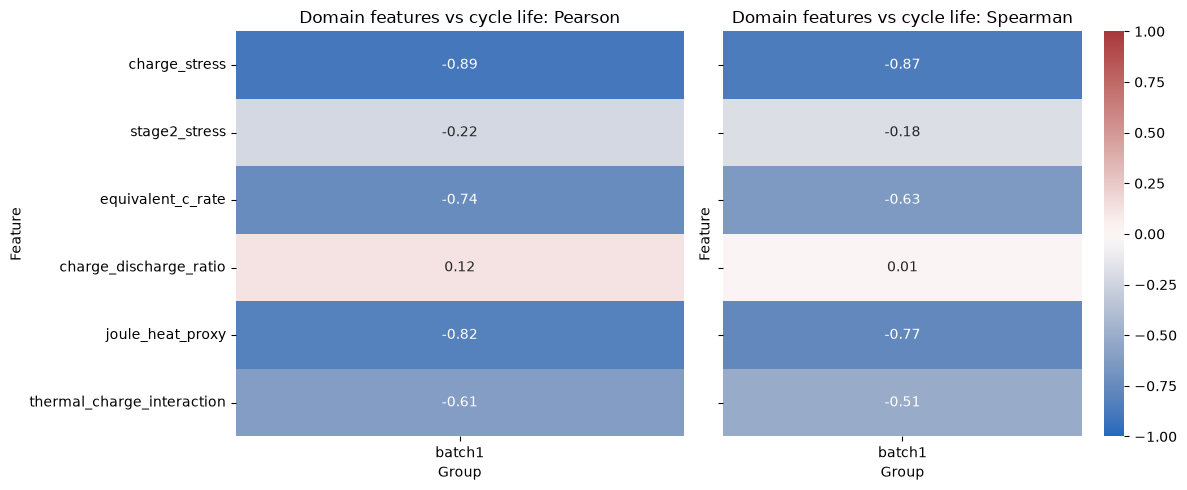

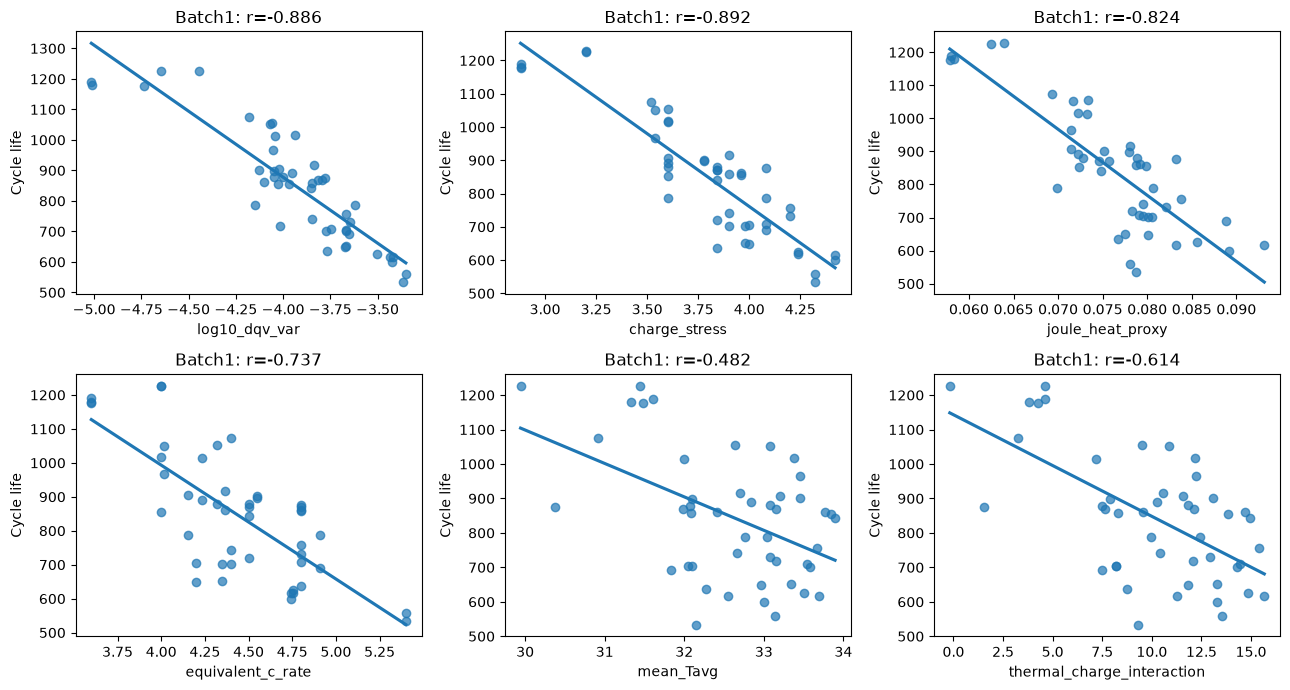

,variable_1,variable_2,Pearson_r
0,first_c_rate,stage2_stress,0.848
1,mean_QCharge,charge_discharge_ratio,-0.957
2,mean_Tavg,thermal_charge_interaction,0.979
3,log10_dqv_var,charge_stress,0.952
4,log10_dqv_var,joule_heat_proxy,0.883
5,charge_stress,equivalent_c_rate,0.858
6,charge_stress,joule_heat_proxy,0.947


,feature,Pearson_r,Spearman_rho
0,log10_dqv_var,-0.886,-0.871
1,charge_stress,-0.892,-0.866
2,stage2_stress,-0.223,-0.182
3,equivalent_c_rate,-0.737,-0.634
4,charge_discharge_ratio,0.124,0.015
5,joule_heat_proxy,-0.824,-0.768
6,thermal_charge_interaction,-0.614,-0.513
7,mean_Tavg,-0.482,-0.371
8,mean_chargetime,0.577,0.613


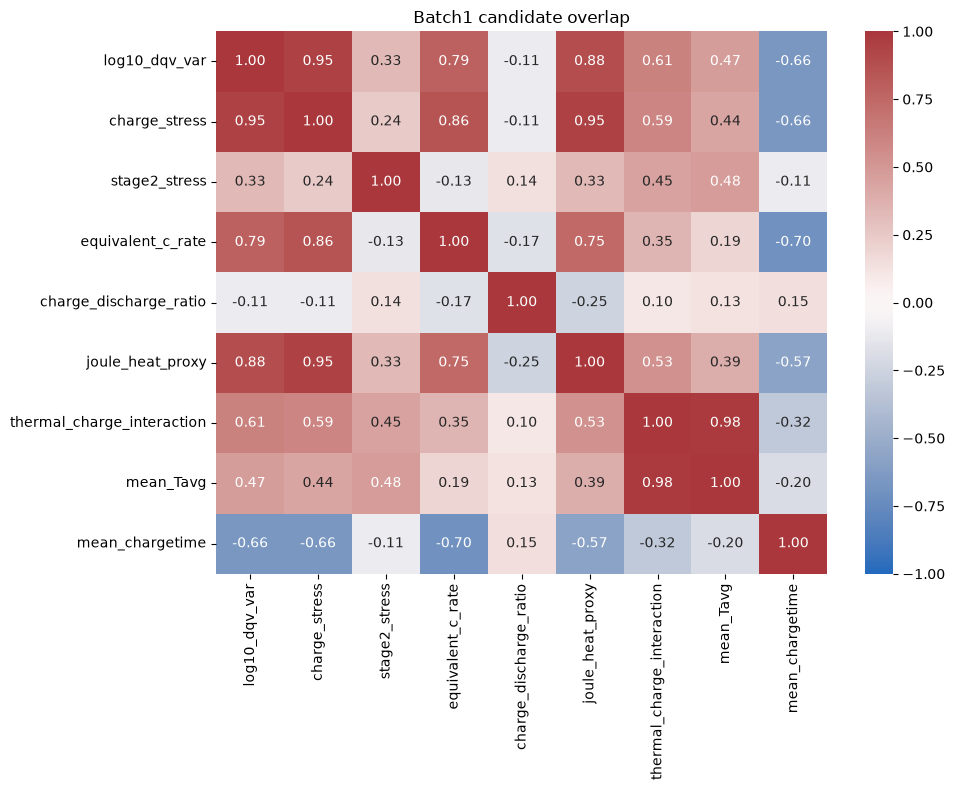

In [5]:
domain_data = base_data.merge(generation_inputs, on=KEYS, validate="one_to_one")
s = domain_data["switch_soc"] / 100
c1, c2 = domain_data["first_c_rate"], domain_data["second_c_rate"]
assert s.between(0, 0.8).all() and c1.gt(0).all() and c2.gt(0).all()
assert domain_data["mean_QCharge"].gt(0).all()

domain_data["charge_stress"] = c1 * s + c2 * (0.8 - s)
domain_data["stage2_stress"] = c2 * (0.8 - s)
domain_data["equivalent_c_rate"] = 0.8 / (s / c1 + (0.8 - s) / c2)
domain_data["charge_discharge_ratio"] = domain_data["mean_QDischarge"] / domain_data["mean_QCharge"]
# IR이 양수가 아닌 경우를 무저항으로 해석하지 않고 발열 근사에서 결측으로 둔다.
positive_ir = domain_data["mean_IR"].where(domain_data["mean_IR"].gt(0))
domain_data["joule_heat_proxy"] = positive_ir * 1.1**2 * domain_data["charge_stress"]
domain_data["thermal_charge_interaction"] = domain_data["charge_stress"] * (domain_data["mean_Tavg"] - 30)
domain_features = ["charge_stress", "stage2_stress", "equivalent_c_rate",
                   "charge_discharge_ratio", "joule_heat_proxy", "thermal_charge_interaction"]

# 단일 충전속도 및 80%에서 전환하는 경계에서 생성식이 맞는지 확인한다.
toy_s = np.array([0.2, 0.8])
assert np.allclose(4 * toy_s + 4 * (0.8 - toy_s), 3.2)
assert np.isclose((4 * (0.8 - toy_s))[-1], 0)
assert np.allclose(0.8 / (toy_s / 4 + (0.8 - toy_s) / 4), 4)
assert np.isfinite(domain_data[domain_features].drop(columns="joule_heat_proxy").to_numpy()).all()

rows = []
for group_name, group in [("batch1", domain_data)]:
    for feature in domain_features:
        valid = group[[feature, "cycle_life"]].dropna()
        rows.append({"group": group_name, "feature": feature, "n": len(valid),
                     "Pearson_r": valid[feature].corr(valid["cycle_life"]),
                     "Spearman_rho": valid[feature].corr(valid["cycle_life"], method="spearman")})
domain_stats = pd.DataFrame(rows)
group_order = ["batch1"]
pearson = domain_stats.pivot(index="feature", columns="group", values="Pearson_r").reindex(
    index=domain_features, columns=group_order)
spearman = domain_stats.pivot(index="feature", columns="group", values="Spearman_rho").reindex(
    index=domain_features, columns=group_order)
display(pd.concat({"Pearson": pearson, "Spearman": spearman}, axis=1).round(3))
print("발열 후보 표본 수:", domain_stats.loc[domain_stats["feature"].eq("joule_heat_proxy"),
                                         ["group", "n"]].to_dict("records"))
print("충·방전 용량비 > 1인 셀:", domain_data["charge_discharge_ratio"].gt(1).sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, matrix, label in zip(axes, [pearson, spearman], ["Pearson", "Spearman"]):
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
                cbar=ax is axes[1], ax=ax)
    ax.set(title=f"Domain features vs cycle life: {label}", xlabel="Group", ylabel="Feature")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
plot_features = ["log10_dqv_var", "charge_stress", "joule_heat_proxy",
                 "equivalent_c_rate", "mean_Tavg", "thermal_charge_interaction"]
for ax, feature in zip(axes.flat, plot_features):
    group = domain_data[[feature, "cycle_life"]].dropna()
    r = group[feature].corr(group["cycle_life"])
    sns.regplot(data=group, x=feature, y="cycle_life", ci=None,
                scatter_kws={"alpha": 0.7}, ax=ax)
    ax.set(title=f"Batch1: r={r:.3f}", xlabel=feature, ylabel="Cycle life")
plt.tight_layout()
plt.show()

# 정책·초기 측정 후보와 파생 후보의 중복을 확인한다.
joint_corr = domain_data[base_features + domain_features].corr()
pair_rows = []
for i, left in enumerate(joint_corr.columns):
    for right in joint_corr.columns[i + 1:]:
        value = joint_corr.loc[left, right]
        if abs(value) >= 0.8:
            pair_rows.append({"variable_1": left, "variable_2": right, "Pearson_r": value})
domain_strong_pairs = pd.DataFrame(pair_rows)
display(domain_strong_pairs.round(3))
# 로그를 포함한 후보들의 수명 관계와 실제 중복을 같은 46개 셀에서 확인한다.
review_features = ["log10_dqv_var", *domain_features, "mean_Tavg", "mean_chargetime"]
review_life = pd.DataFrame({
    "feature": review_features,
    "Pearson_r": [domain_data[f].corr(domain_data["cycle_life"]) for f in review_features],
    "Spearman_rho": [domain_data[f].corr(domain_data["cycle_life"], method="spearman") for f in review_features]
})
display(review_life.round(3))
review_corr = domain_data[review_features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(review_corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Batch1 candidate overlap")
plt.tight_layout()
plt.show()


## 후보와 수명의 관계

| 후보 | 수명 Pearson r | 선택 근거 |
|---|---:|---|
| 로그 지표 | −0.886 | 초기 열화 반응을 관측한 대표 후보로 선택 |
| 전체 충전 부담 | −0.892 | 로그와 r=0.952로 겹치고 수명 관계의 차이가 작아 직접 입력에서 제외. 온도 조합의 생성 재료로 사용 |
| 저항 발열 근사 | −0.824 | 로그와 r=0.883, 전체 부담과 r=0.947로 겹쳐 직접 입력에서 제외 |
| 2단계 충전 부담 | −0.223 | 단독 관계가 약하고 1단계 속도와 r=0.848로 겹쳐 제외 |
| 이상적 평균 충전속도 | −0.737 | 정책의 시간 관점을 반영한 후보. 로그와 r=0.786으로 겹침이 남아 추가 효과를 모델링에서 확인 |
| 충·방전 용량비 | +0.124 | 관계가 약하고 46개 중 39개가 1을 넘어 손실량으로 해석하기 어려워 제외 |
| Tavg·충전 부담 조합 | −0.614 | 온도와 충전 부담의 조합을 반영한 후보. Tavg와 r=0.979로 겹치므로 두 값을 동시에 사용하지 않음 |

### 세 후보의 역할과 중복

- L: `log10_dqv_var` — 초기 열화 반응을 관측한 신호.
- E: `equivalent_c_rate` — 0~80% 이상적 충전시간에서 구한 평균 속도.
- T: `thermal_charge_interaction` — `(Tavg−30)×충전 부담`으로 구한 표면온도·정책 조합.

로그와 전체 충전 부담의 수명 관계는 각각 −0.886, −0.892로 비슷하다. 그중 셀에서 관측한 초기 열화를 담는 로그를 대표로 선택한다. 발열도 중복이 높아 직접 입력에서 제외한다.

L–E r=0.786, L–T r=0.610, E–T r=0.351이다. 평균 충전속도는 로그와 여전히 상당히 겹치므로 세 개를 필수 입력으로 고정하지 않는다. 같은 Batch1 CV에서 L → L+E / L+T → L+E+T를 비교한다.

In [6]:
# 생성 재료를 포함한 후보표와 모델 비교용 세 후보를 따로 저장한다.
preview_path = DATA / "batch1_feature_candidates.csv"
preview = domain_data[KEYS + base_features + ["switch_soc"] + domain_features + ["cycle_life"]].copy()
assert len(preview) == 46 and set(preview["batch"]) == {"batch1"}
assert not preview.duplicated(KEYS).any()
assert np.isfinite(preview.drop(columns=KEYS).to_numpy()).all()
preview.to_csv(preview_path, index=False)
pd.testing.assert_frame_equal(pd.read_csv(preview_path), preview, check_dtype=False)

model_candidates = ["log10_dqv_var", "equivalent_c_rate", "thermal_charge_interaction"]
model_data = domain_data[KEYS + model_candidates + ["cycle_life"]].copy()
assert np.isfinite(model_data[model_candidates + ["cycle_life"]].to_numpy()).all()
assert not set(["charge_stress", "joule_heat_proxy", "mean_Tavg", "switch_soc"]) & set(model_candidates)
model_path = DATA / "batch1_model_candidates.csv"
model_data.to_csv(model_path, index=False)
pd.testing.assert_frame_equal(pd.read_csv(model_path), model_data, check_dtype=False)
print(f"생성 후보표: {preview_path}")
print(f"Batch1 모델 후보표: {model_path}")
print(f"셀 {len(model_data)}개 / 비교 후보 {len(model_candidates)}개")
display(model_data.head())


생성 후보표: /Users/u102/workspace_public/021_Data_Analytics_Mini_Projcet/Data_Analytics_MiniProject_Skala/data/processed/batch1_feature_candidates.csv
Batch1 모델 후보표: /Users/u102/workspace_public/021_Data_Analytics_Mini_Projcet/Data_Analytics_MiniProject_Skala/data/processed/batch1_model_candidates.csv
셀 46개 / 비교 후보 3개


,batch,cell_id,log10_dqv_var,equivalent_c_rate,thermal_charge_interaction,cycle_life
0,batch1,1,-5.014861,3.6,4.618792,1190
1,batch1,2,-5.013960,3.6,3.831305,1179
2,batch1,3,-4.737000,3.6,4.261202,1177
3,batch1,4,-4.442613,4.0,-0.184964,1226
4,batch1,5,-4.647744,4.0,4.636428,1227


## 모델링으로 전달

입력 후보는 L·E·T 세 지표이며, target은 원래 사이클 단위 `cycle_life`다. `batch`, `cell_id`는 식별용으로 사용하고 모델에 입력하지 않는다.

모델링에서는 L, L+E, L+T, L+E+T를 같은 Batch1 학습 셀·프로토콜 CV에서 비교해 추가 효과와 모델을 선택한다. 수명과의 단독 상관이 강하다는 이유로 모든 후보를 사용하지 않는다.

Batch2는 변수 생성식과 모델·파라미터를 고정한 뒤 평가하며, Batch3은 모델링에서 제외한다.